# Computing and Exporting SHAP Values of the proposed XGBoost Model 

## Computing SHAP Values for the XGBoost Model

In [ ]:
# Add the parent directory to the system path to allow imports from other folders
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import necessary libraries
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# Load the test dataset
X_test = pd.read_csv("../data/processed/X_test.csv")

# Get the list of feature names
feature_names = X_test.columns.tolist()

# Convert DataFrame to NumPy array for SHAP compatibility
X_test = X_test.values

# Load the trained XGBoost model
xgboost_model = joblib.load("../models/xgboost_model.pkl")

# Inform the user that SHAP summary plot generation is starting
print("Generating SHAP summary plot for XGBoost...")

# Create a SHAP explainer for the XGBoost model
explainer = shap.TreeExplainer(xgboost_model)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

## Exporting SHAP Values of the XGBoost Model to CSV


In [4]:

shap_dir = "../data/shap/"
os.makedirs(shap_dir, exist_ok=True)
shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_file = os.path.join(shap_dir, "xgboost_shap_values.csv")
shap_df.to_csv(shap_file, index=False)
print(f"SHAP values saved to: {shap_file}")

SHAP values saved to: ../data/shap/xgboost_shap_values.csv


# Loading the Exported SHAP Values and Test Data


In [1]:
import pandas as pd

# Load the SHAP values and test data
shap_values_loaded = pd.read_csv("../data/shap/xgboost_shap_values.csv")  # SHAP values for all instances
X_test = pd.read_csv("../data/processed/X_test.csv")  # Input test data
feature_names = X_test.columns.tolist()  # List of feature names

print("Data loaded successfully!")


Data loaded successfully!


# SHAP Plots Generation

## Generate SHAP Summary Plot (dot)


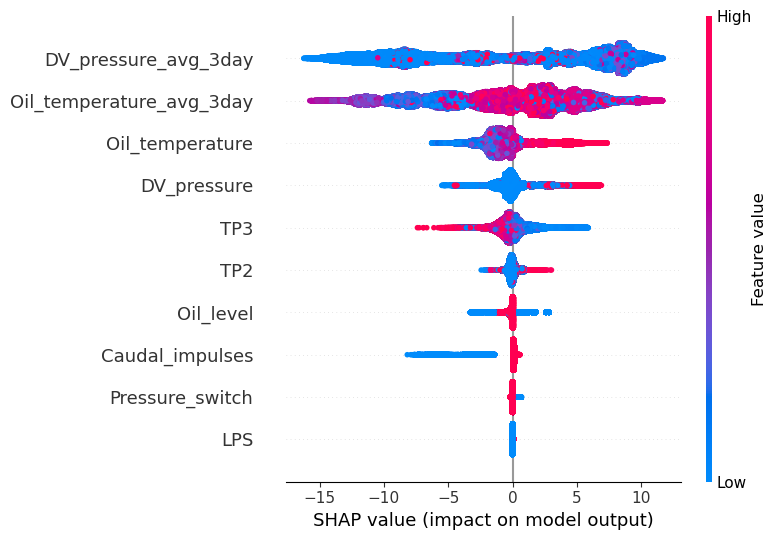

In [5]:
import shap
shap.summary_plot(shap_values_loaded.values, X_test.values, feature_names=feature_names)

## Generating SHAP Dependence Plots for Each Feature

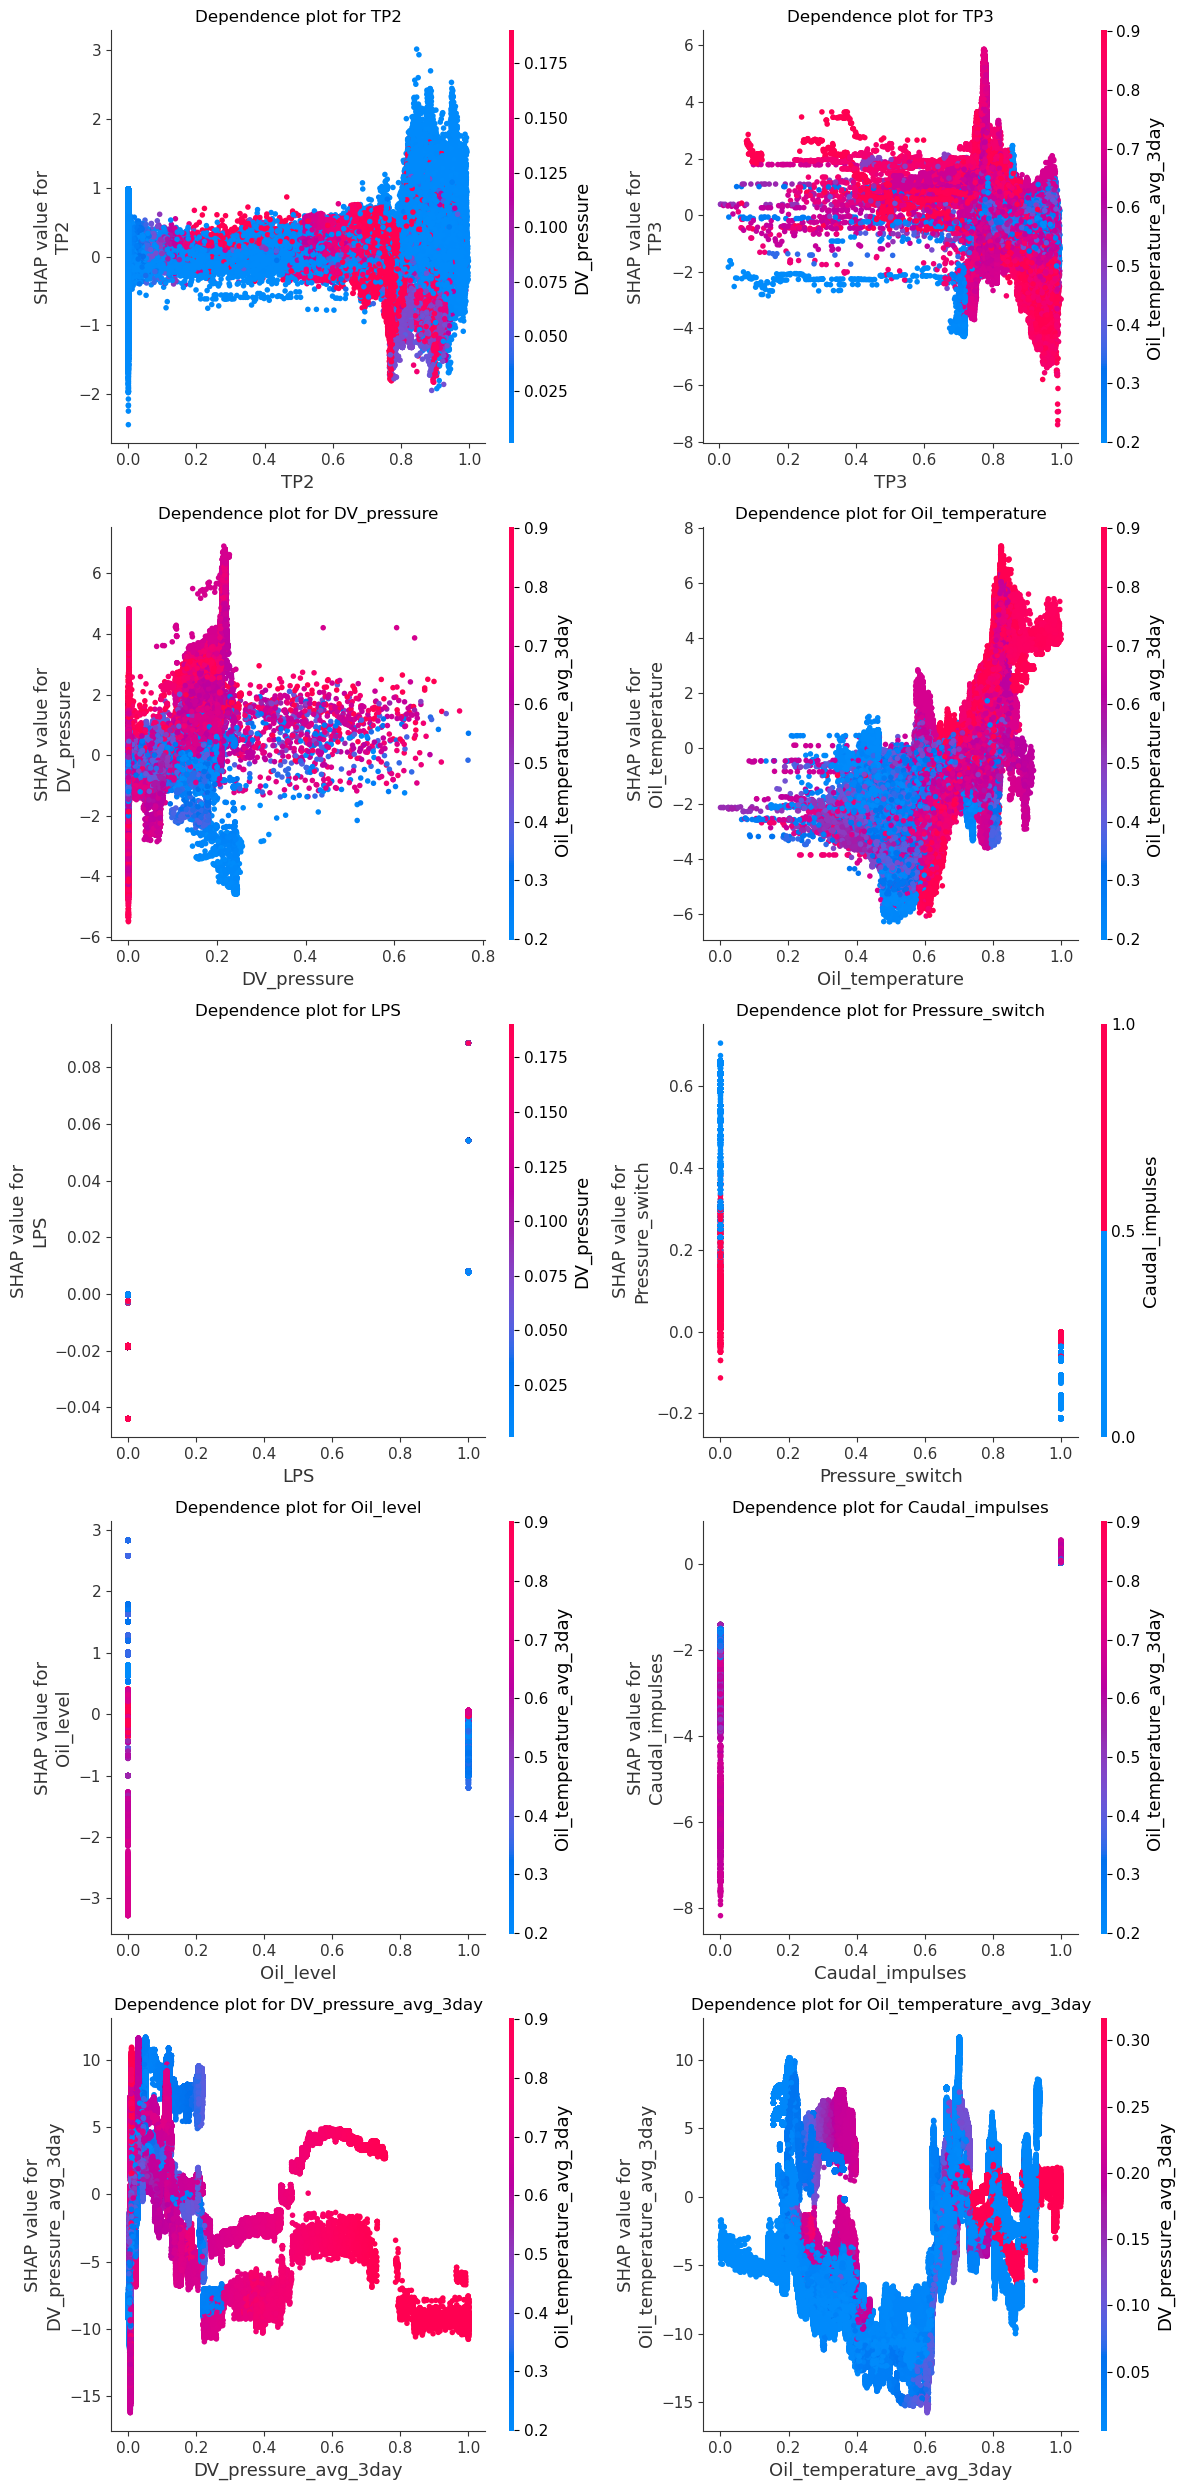

In [6]:
import numpy as np
import shap
import matplotlib.pyplot as plt
import shap

# Define the number of rows and columns for the layout
n_features = len(feature_names)
n_cols = 2  # For example, 2 columns to display the plots
n_rows = int(np.ceil(n_features / n_cols))  # Calculate the required number of rows

# Create a figure with the specified number of rows and columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))

# Flatten the axes for easier manipulation
axes = axes.flatten()

# Create a dependence plot for each feature
for i, feature_name in enumerate(feature_names):
    shap.dependence_plot(
        feature_name,  # Feature name for the dependence plot
        shap_values_loaded.values,  # SHAP values
        X_test.values,  # Input data
        feature_names=feature_names,
        show=False,
        ax=axes[i]  # Assign each plot to a specific axis
    )
    axes[i].set_title(f'Dependence plot for {feature_name}')  # Title for each subplot

# Remove empty axes if the number of features is not a multiple of n_cols
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure as a PNG file
plt.savefig("shap_dependence_color_all.png", dpi=300, bbox_inches='tight')

# Display the plots
plt.show()

# Close the figure to free up memory
plt.close()


## SHAP Summary Plot (Bar) for Both Classes

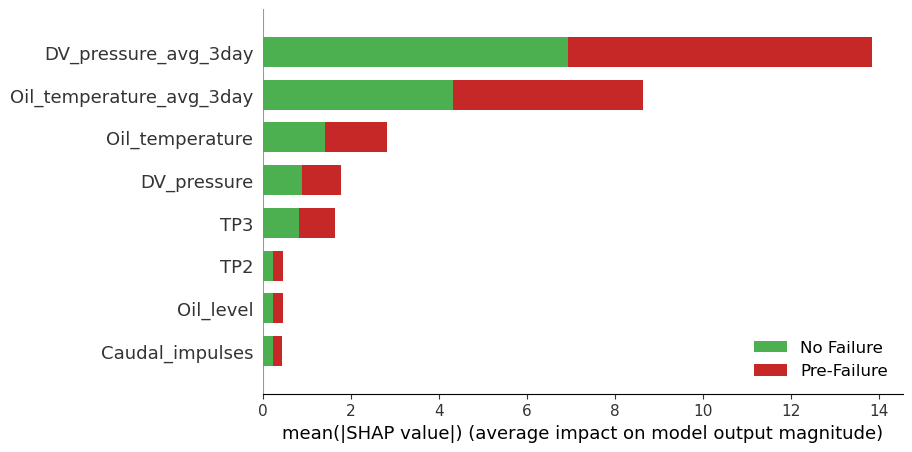

SHAP summary plot (bar) for both classes saved to: ../shap_summary_xgboost_bar_classes.png


In [7]:
import shap
import matplotlib.pyplot as plt
import shap


# Function to assign colors to the classes
def class_colors(i):
    # Define the colors to be used for each class
    colors = ["#4CAF50", "#C62828"]  # Green for "No Failure", Red for "Pre-Failure"
    return colors[i]  # Return the color for the given class index

# Generate the summary plot in "bar" style for both classes
plt.figure(figsize=(14, 6))  # Set the size of the plot

# Create a summary plot (bar plot) for SHAP values of both classes
shap.summary_plot(
    [shap_values_loaded.values, -shap_values_loaded.values],  # SHAP values for both classes
    X_test.values,  # The input data used for generating SHAP values
    feature_names=feature_names,  # Feature names for display
    plot_type="bar",  # Set the plot type to 'bar'
    class_names=["No Failure", "Pre-Failure"],  # Set the class names for the plot legend
    color=class_colors,  # Use the class_colors function to assign colors
    show=False,  # Do not show the plot immediately (it will be saved)
    max_display=8  # Display the top 8 features based on SHAP values
)

# Adjust margins for the plot to prevent overlap and improve layout
plt.subplots_adjust(bottom=0.15, left=0.1, right=0.9)

plt.show()
# Save the plot to a file with high resolution (300 DPI)
plt.savefig("../shap_summary_xgboost_bar_classes.png", dpi=300, bbox_inches="tight")

# Close the plot to free up memory
plt.close()

# Print a confirmation message indicating the location of the saved plot
print("SHAP summary plot (bar) for both classes saved to: ../shap_summary_xgboost_bar_classes.png")


## SHAP Bar Plot by Class

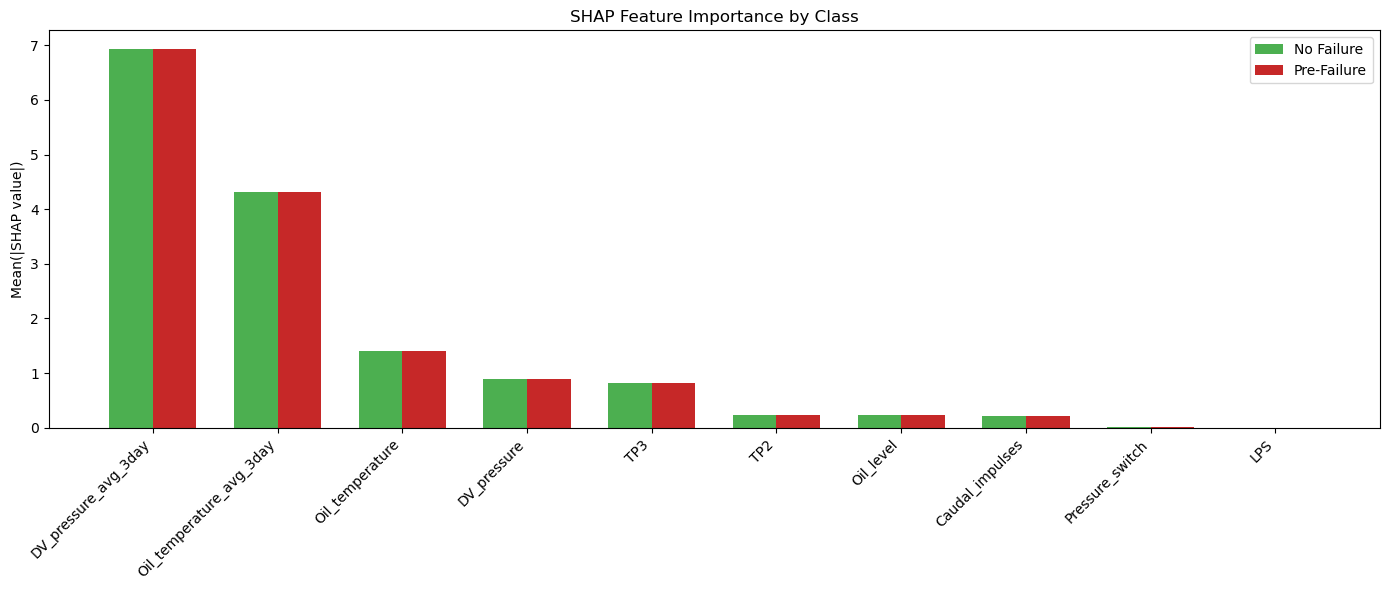

Bar plot SHAP by class saved as: ../Shap.png


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Simulate the two classes (if you only have one SHAP vector, adjust accordingly)
shap_class_0 = shap_values_loaded.values  # SHAP for class 0
shap_class_1 = -shap_values_loaded.values  # SHAP for class 1 (symmetric if binary classification)

# Compute the mean absolute SHAP values per feature
mean_abs_0 = np.abs(shap_class_0).mean(axis=0)  # Mean absolute SHAP values for class 0
mean_abs_1 = np.abs(shap_class_1).mean(axis=0)  # Mean absolute SHAP values for class 1

# Create a DataFrame for easy display
df = pd.DataFrame({
    "Feature": feature_names,  # Feature names
    "No Failure (0)": mean_abs_0,  # Mean absolute SHAP for class 0
    "Pre-Failure (1)": mean_abs_1  # Mean absolute SHAP for class 1
}).sort_values(by="No Failure (0)", ascending=False)  # Sort by class 0 SHAP values

# Bar plot creation
x = np.arange(len(df["Feature"]))  # Bar positions on the x-axis
width = 0.35  # Bar width

# Create the grouped bar plot
plt.figure(figsize=(14, 6))
plt.bar(x - width/2, df["No Failure (0)"], width, label="No Failure", color="#4CAF50")
plt.bar(x + width/2, df["Pre-Failure (1)"], width, label="Pre-Failure", color="#C62828")

# Customizations
plt.xticks(x, df["Feature"], rotation=45, ha="right")  # Rotate x labels for better readability
plt.ylabel("Mean(|SHAP value|)")  # Label for y-axis
plt.title("SHAP Feature Importance by Class")  # Title of the plot
plt.legend()  # Show the legend
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()
plt.savefig("../Shap.png", dpi=300)  # Save the plot as a PNG file with high resolution
plt.close()  # Close the plot to free up memory

# Print confirmation message
print("Bar plot SHAP by class saved as: ../Shap.png")
